# Praktikum Pra-Pemrosesan Data
**Dataset:** House Prices - Advanced Regression Techniques (train.csv)
**Nama:** Patrik
**Mata Kuliah:** Data Mining / Pra-Pemrosesan Data

## Persiapan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


## 1. Import Dataset
Dataset diambil dari file `train.csv` yang berisi 1460 baris dan 81 kolom.

In [2]:
df = pd.read_csv("train.csv")
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.shape


(1460, 81)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## 2. Pembersihan Data

### 2.1 Cek Nilai yang Hilang
Langkah pertama adalah memeriksa berapa banyak nilai yang hilang (missing value) pada tiap kolom.

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"jumlah_hilang": missing, "persen_hilang": missing_pct})
missing_table


,jumlah_hilang,persen_hilang
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


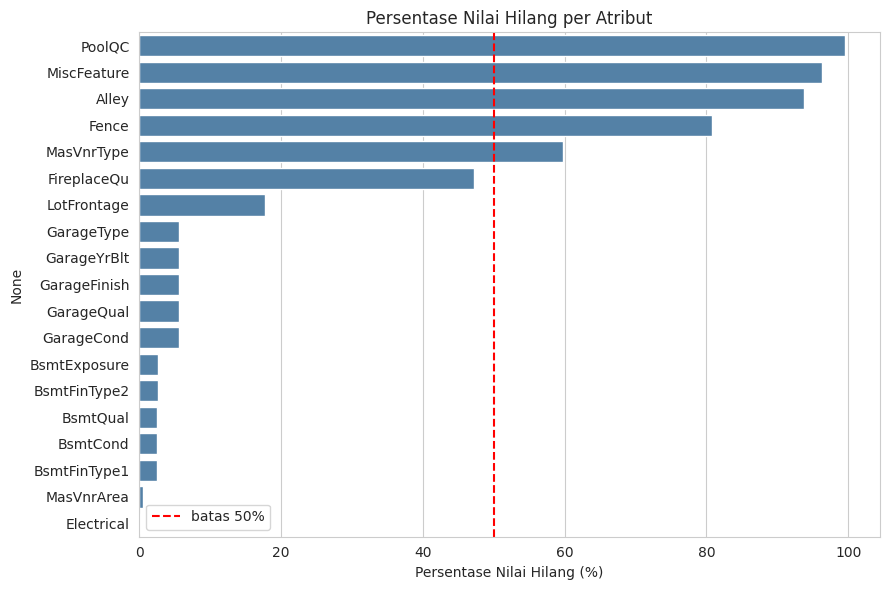

In [6]:
plt.figure(figsize=(9, 6))
sns.barplot(x=missing_table["persen_hilang"], y=missing_table.index, color="steelblue")
plt.axvline(50, color="red", linestyle="--", label="batas 50%")
plt.xlabel("Persentase Nilai Hilang (%)")
plt.title("Persentase Nilai Hilang per Atribut")
plt.legend()
plt.tight_layout()
plt.savefig("plots/01_missing_values.png")
plt.show()


Terlihat ada 5 kolom yang nilai hilangnya lebih dari 50%, yaitu `PoolQC`, `MiscFeature`, `Alley`, `Fence`, dan `MasVnrType`. Kolom-kolom ini sebaiknya dibuang karena terlalu banyak datanya yang kosong sehingga tidak banyak membantu proses analisis.

### 2.2 Hapus Kolom dengan Nilai Hilang > 50%

In [7]:
cols_to_drop = missing_table[missing_table["persen_hilang"] > 50].index.tolist()
print("Kolom yang dibuang:", cols_to_drop)

df = df.drop(columns=cols_to_drop)
print("Shape setelah kolom dibuang:", df.shape)


Kolom yang dibuang: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']
Shape setelah kolom dibuang: (1460, 76)


### 2.3 Tangani Nilai Hilang yang Tersisa
Untuk kolom numerik, nilai yang hilang diisi dengan **median**, karena median lebih tahan terhadap outlier dibanding rata-rata. Untuk kolom kategorik, nilai yang hilang diisi dengan **modus** (nilai yang paling sering muncul).

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include="object").columns

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Total nilai hilang setelah penanganan:", df.isnull().sum().sum())


Total nilai hilang setelah penanganan: 0


/tmp/ipykernel_167/2437032038.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


## 3. Deteksi dan Penanganan Outlier

Deteksi outlier dilakukan menggunakan **boxplot** pada beberapa atribut numerik yang penting, yaitu `SalePrice`, `GrLivArea`, `LotArea`, `TotalBsmtSF`, dan `1stFlrSF`.

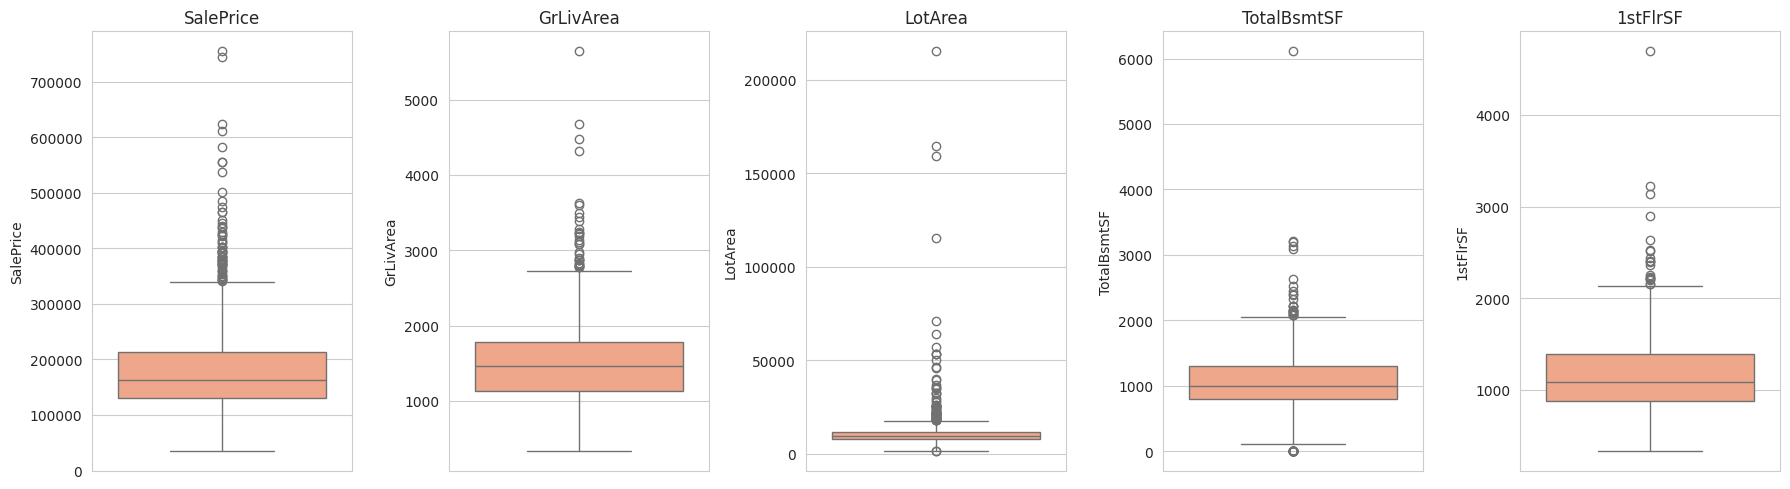

In [9]:
outlier_cols = ["SalePrice", "GrLivArea", "LotArea", "TotalBsmtSF", "1stFlrSF"]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 5))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightsalmon")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("plots/02_boxplot_before.png")
plt.show()


Outlier dihitung menggunakan metode **IQR (Interquartile Range)**: nilai di luar rentang `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` dianggap outlier.

In [10]:
def batas_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

for col in outlier_cols:
    lower, upper = batas_iqr(df[col])
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outlier} outlier (batas: {lower:.1f} - {upper:.1f})")


SalePrice: 61 outlier (batas: 3937.5 - 340037.5)
GrLivArea: 31 outlier (batas: 158.6 - 2747.6)
LotArea: 69 outlier (batas: 1481.5 - 17673.5)
TotalBsmtSF: 61 outlier (batas: 42.0 - 2052.0)
1stFlrSF: 20 outlier (batas: 118.1 - 2155.1)


**Keputusan penanganan outlier:** outlier tidak dihapus, melainkan **disesuaikan (capping/winsorizing)** ke batas bawah/atas IQR.

**Alasan:**
- Dataset hanya berisi 1460 baris, sehingga menghapus baris outlier akan mengurangi jumlah data secara signifikan.
- Rumah dengan ukuran atau harga yang ekstrem bukan berarti data salah input, melainkan tetap merupakan data yang valid (misalnya rumah mewah yang memang berukuran besar).
- Dengan capping, pengaruh nilai ekstrem terhadap model tetap berkurang tanpa kehilangan baris data.

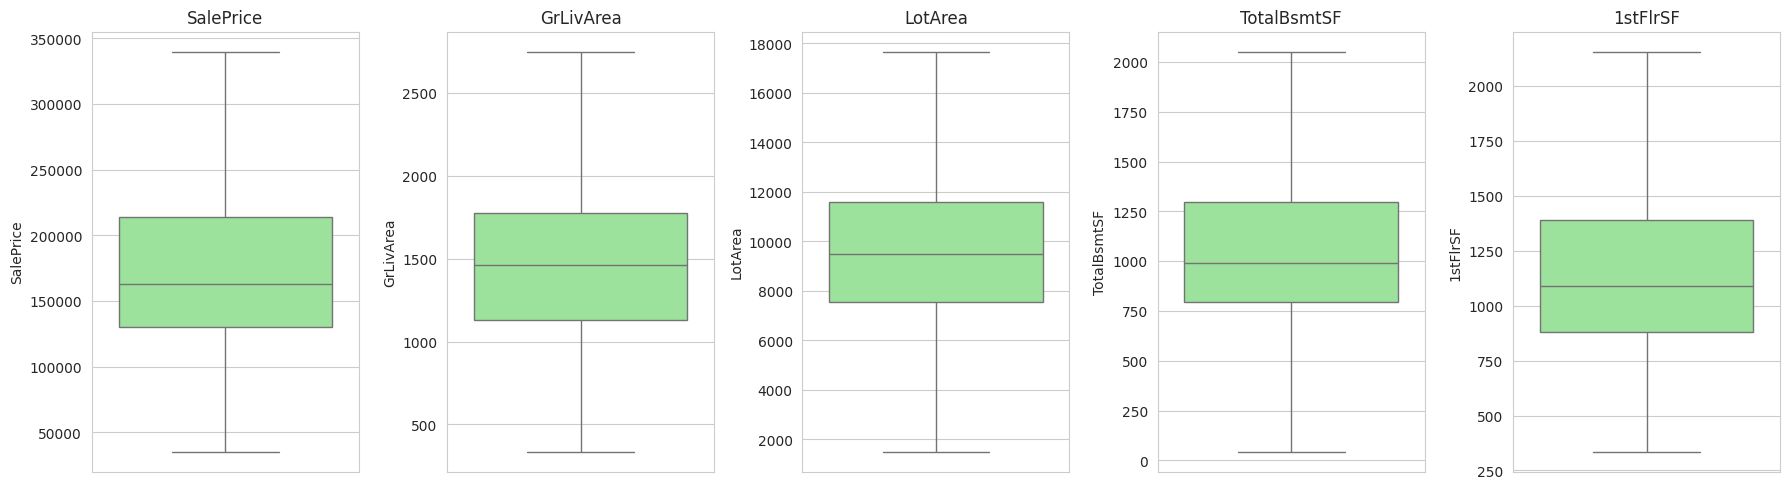

In [11]:
for col in outlier_cols:
    lower, upper = batas_iqr(df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 5))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightgreen")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("plots/03_boxplot_after.png")
plt.show()


## 4. Transformasi Data

### 4.1 Normalisasi / Standarisasi
Atribut numerik distandarisasi menggunakan `StandardScaler` agar memiliki rata-rata 0 dan standar deviasi 1. Kolom `Id` dan `SalePrice` (target) tidak ikut distandarisasi.

In [12]:
num_cols_scale = [c for c in num_cols if c not in ["Id", "SalePrice"]]
scaler = StandardScaler()
df_scaled_num = pd.DataFrame(
    scaler.fit_transform(df[num_cols_scale]),
    columns=num_cols_scale,
    index=df.index,
)
df_scaled_num.head()


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,0.073375,-0.220875,-0.333244,0.651479,-0.517200,1.050994,0.878668,0.514104,0.575425,-0.288653,...,0.351000,-0.752176,0.216503,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-1.599111,0.138777
1,-0.872563,0.460320,-0.013189,-0.071836,2.179628,0.156734,-0.429577,-0.570750,1.171992,-0.288653,...,-0.060731,1.626195,-0.704483,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-0.489110,-0.614439
2,0.073375,-0.084636,0.446022,0.651479,-0.517200,0.984752,0.830215,0.325915,0.092907,-0.288653,...,0.631726,-0.752176,-0.070361,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,0.990891,0.138777
3,0.309859,-0.447940,-0.027104,0.651479,-0.517200,-1.863632,-0.720298,-0.570750,-0.499274,-0.288653,...,0.790804,-0.752176,-0.176048,4.092524,-0.116339,-0.270208,-0.068692,-0.087688,-1.599111,-1.367655
4,0.073375,0.641972,1.283733,1.374795,-0.517200,0.951632,0.733308,1.366489,0.463568,-0.288653,...,1.698485,0.780197,0.563760,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,2.100892,0.138777


### 4.2 One-Hot Encoding
Atribut kategorik diubah menjadi format numerik menggunakan **one-hot encoding**, karena sebagian besar algoritma machine learning hanya bisa memproses data numerik.

In [13]:
df_encoded_cat = pd.get_dummies(df[cat_cols], drop_first=True)
print("Jumlah kolom kategorik sebelum encoding:", len(cat_cols))
print("Jumlah kolom setelah one-hot encoding:", df_encoded_cat.shape[1])
df_encoded_cat.head()


Jumlah kolom kategorik sebelum encoding: 38
Jumlah kolom setelah one-hot encoding: 197


,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False
1,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False
2,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


In [14]:
df_final = pd.concat(
    [df[["Id"]].reset_index(drop=True),
     df_scaled_num.reset_index(drop=True),
     df_encoded_cat.reset_index(drop=True),
     df[["SalePrice"]].reset_index(drop=True)],
    axis=1,
)
print("Shape setelah transformasi:", df_final.shape)
df_final.head()


Shape setelah transformasi: (1460, 235)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SalePrice
0,1,0.073375,-0.220875,-0.333244,0.651479,-0.517200,1.050994,0.878668,0.514104,0.575425,...,False,False,False,True,False,False,False,True,False,208500.0
1,2,-0.872563,0.460320,-0.013189,-0.071836,2.179628,0.156734,-0.429577,-0.570750,1.171992,...,False,False,False,True,False,False,False,True,False,181500.0
2,3,0.073375,-0.084636,0.446022,0.651479,-0.517200,0.984752,0.830215,0.325915,0.092907,...,False,False,False,True,False,False,False,True,False,223500.0
3,4,0.309859,-0.447940,-0.027104,0.651479,-0.517200,-1.863632,-0.720298,-0.570750,-0.499274,...,False,False,False,True,False,False,False,False,False,140000.0
4,5,0.073375,0.641972,1.283733,1.374795,-0.517200,0.951632,0.733308,1.366489,0.463568,...,False,False,False,True,False,False,False,True,False,250000.0


## 5. Reduksi Dimensi

### 5.1 Analisis Korelasi
Analisis korelasi dilakukan pada atribut numerik asli untuk melihat atribut mana yang saling berkorelasi tinggi (redundan).

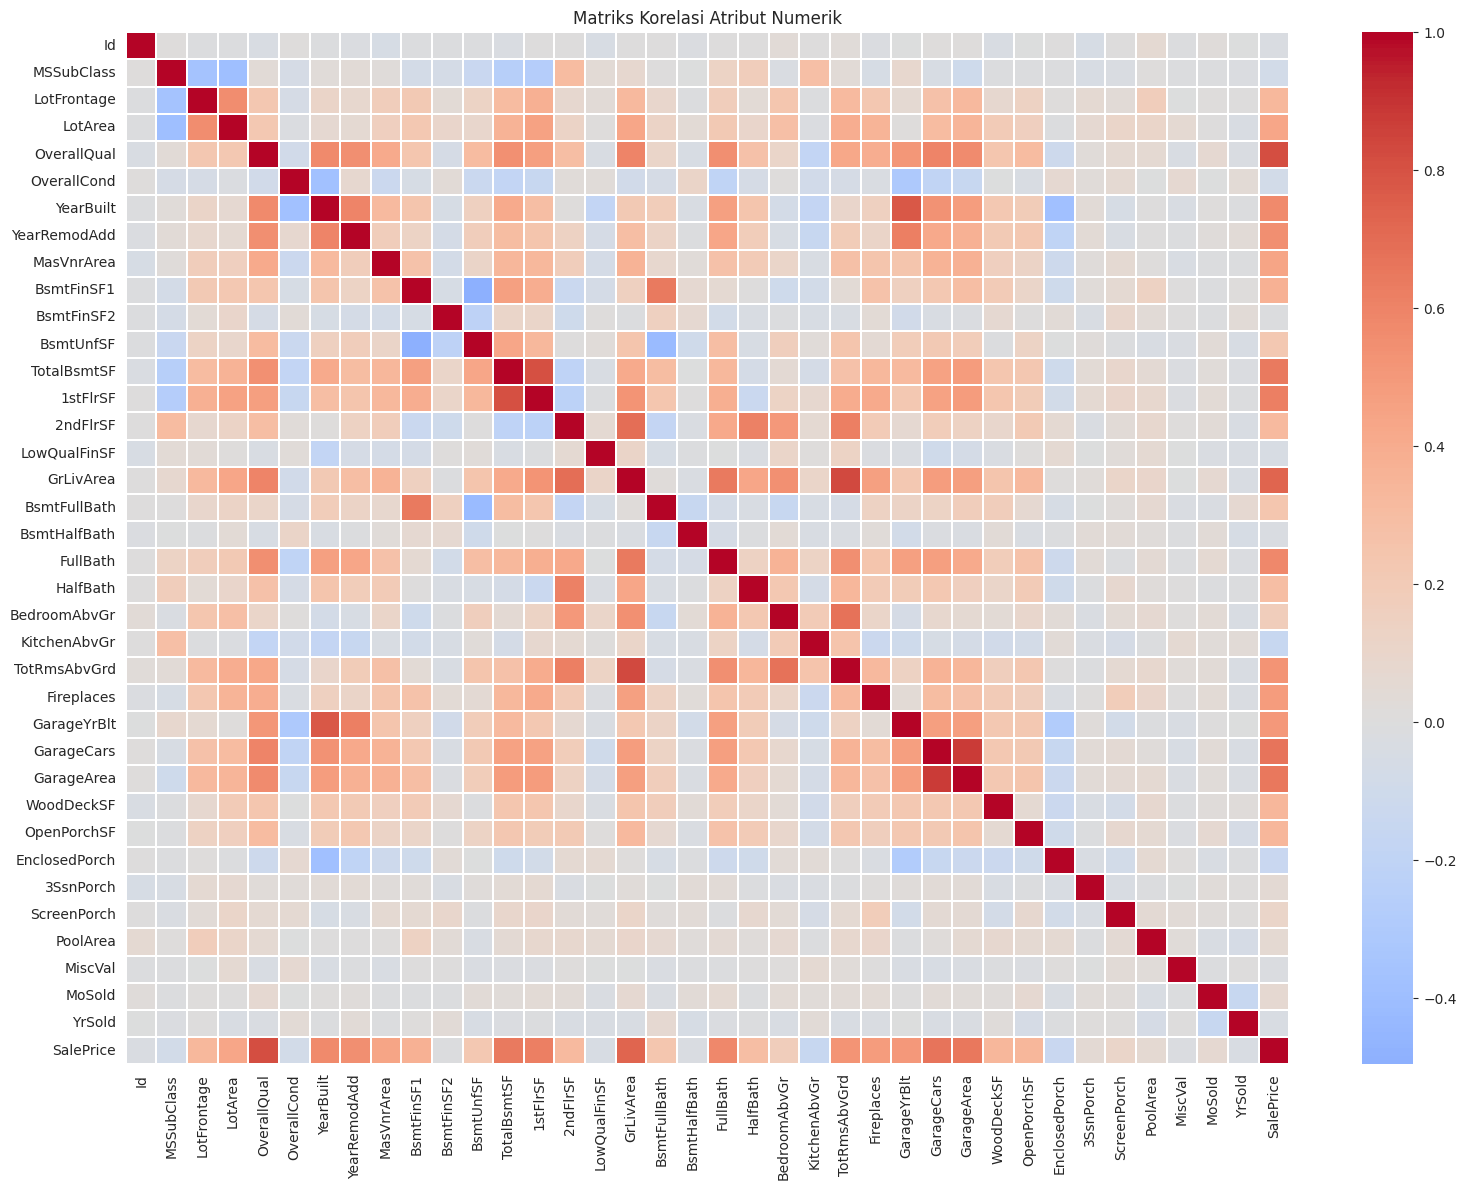

In [15]:
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Matriks Korelasi Atribut Numerik")
plt.tight_layout()
plt.savefig("plots/04_correlation_heatmap.png")
plt.show()


In [16]:
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(val, 3)))

print("Pasangan atribut dengan korelasi tinggi (>0.8):")
for pair in high_corr_pairs:
    print(pair)


Pasangan atribut dengan korelasi tinggi (>0.8):
('OverallQual', 'SalePrice', np.float64(0.817))
('TotalBsmtSF', '1stFlrSF', np.float64(0.807))
('GrLivArea', 'TotRmsAbvGrd', np.float64(0.836))
('GarageCars', 'GarageArea', np.float64(0.882))


Dari hasil di atas, ditemukan beberapa pasangan atribut yang berkorelasi tinggi, misalnya `GarageCars` dengan `GarageArea`, dan `GrLivArea` dengan `TotRmsAbvGrd`. Untuk mengurangi redundansi, salah satu atribut dari tiap pasangan dibuang. Atribut `SalePrice` tetap dipertahankan karena merupakan target/label, bukan atribut prediktor.

In [17]:
cols_drop_corr = list(set([p[1] for p in high_corr_pairs if p[1] != "SalePrice"]))
print("Kolom yang dibuang karena korelasi tinggi:", cols_drop_corr)

df_final_reduced = df_final.drop(columns=[c for c in cols_drop_corr if c in df_final.columns])
print("Shape setelah pembuangan atribut berkorelasi tinggi:", df_final_reduced.shape)


Kolom yang dibuang karena korelasi tinggi: ['GarageArea', 'TotRmsAbvGrd', '1stFlrSF']
Shape setelah pembuangan atribut berkorelasi tinggi: (1460, 232)


### 5.2 PCA (Principal Component Analysis)
Setelah analisis korelasi, dilakukan PCA untuk mengurangi dimensi data lebih lanjut sambil tetap mempertahankan sebagian besar informasi (variansi) data.

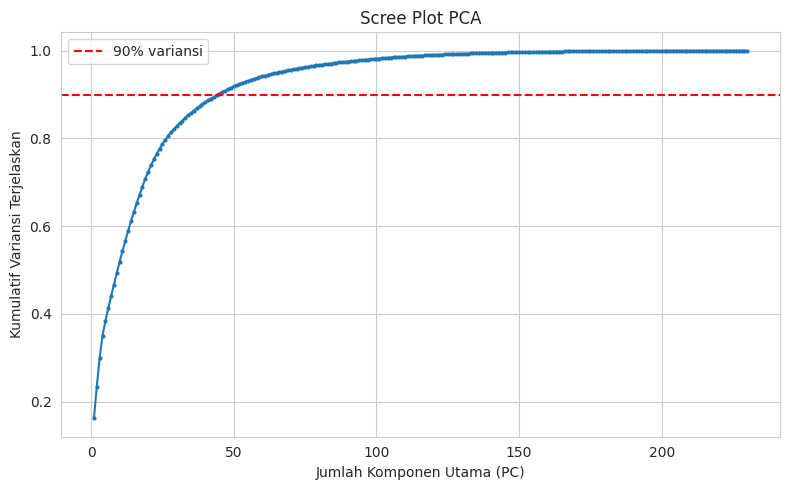

In [18]:
X_for_pca = df_final_reduced.drop(columns=["Id", "SalePrice"])

pca_full = PCA()
pca_full.fit(X_for_pca)
explained_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker="o", markersize=2)
plt.axhline(0.90, color="red", linestyle="--", label="90% variansi")
plt.xlabel("Jumlah Komponen Utama (PC)")
plt.ylabel("Kumulatif Variansi Terjelaskan")
plt.title("Scree Plot PCA")
plt.legend()
plt.tight_layout()
plt.savefig("plots/05_pca_scree.png")
plt.show()


In [19]:
n_components_90 = np.argmax(explained_var >= 0.90) + 1
print(f"Jumlah komponen PCA untuk menjelaskan >=90% variansi: {n_components_90}")

pca = PCA(n_components=n_components_90)
pca_result = pca.fit_transform(X_for_pca)
df_pca = pd.DataFrame(pca_result, columns=[f"PC{i+1}" for i in range(n_components_90)])
print("Shape data hasil PCA:", df_pca.shape)
df_pca.head()


Jumlah komponen PCA untuk menjelaskan >=90% variansi: 45
Shape data hasil PCA: (1460, 45)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC36,PC37,PC38,PC39,PC40,PC41,PC42,PC43,PC44,PC45
0,2.392409,0.107869,-1.597825,-1.908765,0.092928,-0.814259,-1.532492,-0.857749,-0.251082,-0.540575,...,0.275128,-0.137703,0.319650,-0.096667,0.034388,-0.170756,0.079942,-0.182390,-0.045050,0.082702
1,-0.130403,-1.308627,1.585410,0.001171,-1.722399,-0.466420,0.711645,2.604572,-0.843515,1.878668,...,-0.034697,0.315339,-0.953067,0.124751,0.410104,-0.455140,-0.010522,-0.343162,0.443527,1.349199
2,2.980352,0.466791,-0.756374,-1.352604,-0.250233,-0.529949,-0.245961,-0.210899,-0.535433,-0.768200,...,0.024842,-0.098900,0.034694,0.286594,-0.079964,-0.785141,-0.055953,0.114824,-0.138235,0.373627
3,-0.941785,1.411121,0.668213,-0.257044,0.436179,2.346313,-1.137844,-1.281016,-0.648092,-0.879939,...,-0.990692,0.588456,0.657343,-0.816916,-0.545045,0.090093,-0.110395,0.690447,-0.396759,-0.737229
4,4.802286,1.147257,0.769738,-1.149740,0.034659,-0.513493,0.131126,0.322101,-0.976897,-0.467410,...,-0.081886,0.443472,-0.198118,-0.266169,0.515133,-0.135792,-0.091437,0.044051,0.076990,0.294232


## 6. Simpan Dataset Akhir

Dataset akhir yang disimpan adalah dataset hasil pembersihan, transformasi (standarisasi + one-hot encoding), dan pembuangan atribut berkorelasi tinggi. Dataset ini belum di-PCA supaya nama atributnya masih bisa dibaca/diinterpretasi. Hasil PCA disimpan terpisah sebagai contoh reduksi dimensi lanjutan.

In [20]:
df_final_reduced.to_csv("house_prices_clean.csv", index=False)
df_pca.to_csv("house_prices_pca.csv", index=False)

print("Dataset awal        :", (1460, 81))
print("Dataset bersih final:", df_final_reduced.shape)
print("Dataset hasil PCA   :", df_pca.shape)
print("File disimpan: house_prices_clean.csv, house_prices_pca.csv")


Dataset awal        : (1460, 81)
Dataset bersih final: (1460, 232)
Dataset hasil PCA   : (1460, 45)
File disimpan: house_prices_clean.csv, house_prices_pca.csv


## 7. Kesimpulan

1. Dari 81 kolom awal, 5 kolom dibuang karena nilai hilangnya lebih dari 50%.
2. Nilai hilang yang tersisa berhasil ditangani menggunakan median (numerik) dan modus (kategorik) sehingga tidak ada lagi nilai kosong.
3. Outlier pada atribut numerik penting ditangani dengan metode capping (IQR) agar data ekstrem tidak terlalu mendominasi tanpa mengurangi jumlah baris data.
4. Atribut numerik telah distandarisasi dan atribut kategorik telah di-encode menggunakan one-hot encoding.
5. Reduksi dimensi dilakukan melalui analisis korelasi (membuang atribut redundan) dan PCA, sehingga jumlah fitur berkurang secara signifikan namun tetap mempertahankan sebagian besar informasi data.